In [1]:

!wget https://cainvas-static.s3.amazonaws.com/media/user_data/Yuvnish17/data.zip
!unzip -qo data.zip


--2026-03-09 22:26:54--  https://cainvas-static.s3.amazonaws.com/media/user_data/Yuvnish17/data.zip
Resolving cainvas-static.s3.amazonaws.com (cainvas-static.s3.amazonaws.com)... 3.5.209.174, 16.12.40.91, 3.5.209.137, ...
Connecting to cainvas-static.s3.amazonaws.com (cainvas-static.s3.amazonaws.com)|3.5.209.174|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28437489 (27M) [application/x-zip-compressed]
Saving to: ‘data.zip’

data.zip            100%[===================>]  27.12M  9.42MB/s    in 2.9s    

2026-03-09 22:26:58 (9.42 MB/s) - ‘data.zip’ saved [28437489/28437489]



In [2]:
!pip install opencv-python --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 19.1 MB/s eta 0:00:00


In [3]:
import requests
import cv2
import numpy as np
url = "https://github.com/seika-afk/HandWritten-Equation-Solver/raw/main/4_plus_4.png"
resp = requests.get(url)
image_arr = np.asarray(bytearray(resp.content), dtype=np.uint8)
img = cv2.imdecode(image_arr, cv2.IMREAD_GRAYSCALE)

cv2.imwrite("4_plus_4.png", img)

True

In [4]:
import os
import random
import numpy as np


In [5]:
def gimme_data_arrays(dir):
  images=[]
  labels=[]
  for folder in os.listdir(dir):
    path=os.path.join(dir,folder)
    for image in os.listdir(path):
      img=cv2.imread(os.path.join(path,image),cv2.IMREAD_GRAYSCALE)
      img=cv2.resize(img,(32,32))
      images.append(img)
      labels.append(folder)
  data=zip(images,labels)
  data=list(data)

  random.shuffle(data)

  images,labels=zip(*data)
  return np.array(images),labels


In [6]:
dir="/content/data/dataset"

In [7]:
images,labels=gimme_data_arrays(dir)

#### Label Encoding


In [8]:
images.shape

(7600, 32, 32)

In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
le=LabelEncoder()
Y=le.fit_transform(labels)


array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
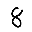

In [11]:
images[0]

In [12]:
label_mapping={i:label for i ,label in enumerate(le.classes_)}
label_mapping

{0: np.str_('0'),
 1: np.str_('1'),
 2: np.str_('2'),
 3: np.str_('3'),
 4: np.str_('4'),
 5: np.str_('5'),
 6: np.str_('6'),
 7: np.str_('7'),
 8: np.str_('8'),
 9: np.str_('9'),
 10: np.str_('add'),
 11: np.str_('div'),
 12: np.str_('mul'),
 13: np.str_('sub')}

In [13]:
X=images
Y=np.array(Y)

In [14]:
X.shape,Y.shape

((7600, 32, 32), (7600,))

In [15]:
X=np.expand_dims(X,axis=-1)
X.shape

(7600, 32, 32, 1)

In [16]:
from sklearn.model_selection import train_test_split
X = X / 255.0

In [17]:
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [18]:

len(X_train)

6080

#### Model


In [19]:
!pip install tensorflow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 747.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 123.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 79.9 MB/s eta 0:00:00


In [20]:
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
from tensorflow.keras.models import Sequential

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [21]:

model=Sequential()
model.add(Conv2D(32,(3,3),activation="relu",padding="same",input_shape=(32,32,1),))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation="relu",padding="same",input_shape=(32,32,1)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation="relu",padding="same",input_shape=(32,32,1)))
model.add(MaxPooling2D(2,2))

model.add(Dropout(0.5))

model.add(Flatten())

model.add(Dense(64,activation="relu"))
model.add(Dense(14,activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,718 (877.80 KB)

 Trainable params: 224,718 (877.80 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
import tensorflow

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

es=EarlyStopping(
    monitor="val_accuracy",
    patience=15,
    restore_best_weights=True

)

In [25]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [26]:
hist=model.fit(X_train,y_train,epochs=10,validation_data=(X_test,y_test),callbacks=[es])

Epoch 1/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.4018 - loss: 1.8594 - val_accuracy: 0.7026 - val_loss: 0.9854
Epoch 2/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.7952 - loss: 0.6400 - val_accuracy: 0.8961 - val_loss: 0.3883
Epoch 3/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8929 - loss: 0.3401 - val_accuracy: 0.9138 - val_loss: 0.2867
Epoch 4/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9164 - loss: 0.2570 - val_accuracy: 0.9362 - val_loss: 0.2205
Epoch 5/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9423 - loss: 0.1755 - val_accuracy: 0.9342 - val_loss: 0.2367
Epoch 6/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9525 - loss: 0.1427 - val_accuracy: 0.9546 - val_loss: 0.1572
Epoch 7/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9543 - loss: 0.1371 - val_accuracy: 0.9546 - val_loss: 0.1766
Epoch 8/10
190/190 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9668 - loss: 0.1007 - val_accu

In [67]:
model.save("predict_num.keras")

In [28]:
def processIMG(path):

  image=cv2.imread(path,cv2.IMREAD_GRAYSCALE)
  image=cv2.resize(image,(32,32))
  image=np.array(image)
  image=image/255.0
  image=np.expand_dims(image,axis=-1)
  image = np.expand_dims(image, axis=0)

  return image

image=processIMG("/content/data/dataset/8/0h1NjYNq.png")



In [29]:
import matplotlib.pyplot as plt

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
PREDICTED LABEL ------ [8]


Text(0.5, 1.0, '[8]')

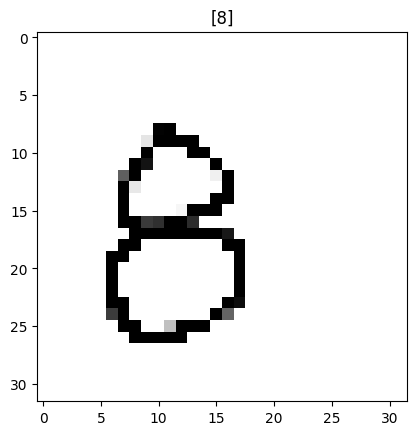

In [30]:

prediction=model.predict(image)
predicted_labels=np.argmax(prediction,axis=1)
print("PREDICTED LABEL ------",predicted_labels)
plt.imshow(image.squeeze(),cmap='gray')
plt.title(predicted_labels)

In [31]:
#math solver


In [32]:
labels = {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: '+', 11: '/', 12: '*', 13: '-'}

In [33]:
# def provide_solution(image_path):

#     image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
#     _, binary = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY_INV)

#     contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#     contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[0])

#     rois = []
#     for c in contours:
#         x, y, w, h = cv2.boundingRect(c)
#         padding = 15
#         roi = image[max(0,y-padding):y+h+padding, max(0,x-padding):x+w+padding]
#         roi = cv2.resize(roi, (32,32))
#         rois.append(roi)

#     rois = np.array(rois) / 255.0
#     rois = np.expand_dims(rois, axis=-1)

#     preds = model.predict(rois)
#     pred_labels = [labels[i] for i in np.argmax(preds, axis=1)]
#     eqn=''.join(pred_labels)
#     sol=eval(eqn)
#     return eqn,sol



In [59]:
def provide_solution(image_path, confidence_threshold=0.7):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    _, binary = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY_INV)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = [c for c in contours if cv2.contourArea(c) > 50]
    contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[0])

    rois = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        padding = 10
        roi = image[max(0,y-padding):y+h+padding, max(0,x-padding):x+w+padding]
        roi = cv2.resize(roi, (32,32))
        rois.append(roi)

    rois = np.array(rois) / 255.0
    rois = np.expand_dims(rois, axis=-1)

    preds = model.predict(rois, verbose=0)
    confidences = np.max(preds, axis=1)
    pred_indices = np.argmax(preds, axis=1)

    pred_labels = []
    for idx, conf in zip(pred_indices, confidences):
        if conf < confidence_threshold:
            pred_labels.append(f"[?{labels[idx]}]")
        else:
            pred_labels.append(labels[idx])

    eqn = ''.join([p.strip('[]?') for p in pred_labels])
    return eqn,eval(eqn)

In [62]:

provide_solution("/content/4_plus_4.png")


('4+4', 8)

In [63]:
provide_solution("/content/data/test_equation4.jpg")

('22+15*15', 247)

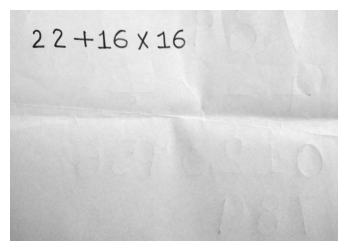

In [44]:
import cv2
import matplotlib.pyplot as plt


image = cv2.imread("/content/data/test_equation4.jpg", cv2.IMREAD_GRAYSCALE)


plt.figure(figsize=(6,3))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()